# Versao 9 - LSTM Hibrida Hierarquica

## Objetivo deste notebook

Este e o notebook central da `versao9`. Aqui propomos uma arquitetura `LSTM` mais forte do que as anteriores, desenhada especificamente para atacar os pontos em que a rede vinha ficando atras das baselines.

A arquitetura combina:

- janelas temporais;
- ramos separados para sinais continuos e estados discretos;
- uma LSTM de contexto entre janelas;
- atencao;
- fusao com `X_tab`.

## Resultados Da Ultima Execucao Registrada

Os artefatos atuais em `artifacts/reports_v9/classificacao_v9_lstm_hibrida/lstm/` mostram:

- o treinamento foi encerrado apos `43` epocas, com melhor checkpoint na epoca `33`
- na melhor epoca, o `macro-F1` de treino foi `0.9698` e o de validacao foi `0.9596`, produzindo um gap de `0.0102`
- validacao da `LSTM` hibrida: `accuracy = 0.9551`, `macro-F1 = 0.9596`, `balanced accuracy = 0.9608`
- teste da `LSTM` hibrida: `accuracy = 0.9224`, `macro-F1 = 0.9268`, `balanced accuracy = 0.9415`
- variacao em relacao a `versao8`: `0.0119` em `accuracy`, `0.0304` em `macro-F1` e `0.0224` em `balanced accuracy`
- variacao em relacao a melhor `LSTM` anterior (`versao6`): `-0.0209` em `accuracy`, `0.0083` em `macro-F1` e `0.0048` em `balanced accuracy`
- classes mais dificeis no teste: classe `7` com `F1 = 0.7500` e `recall = 0.8571`; classe `4` com `F1 = 0.8167` e `recall = 0.9423`; classe `0` com `F1 = 0.8820` e `recall = 0.7978`

Leitura interpretativa: a `versao9` representou um salto real sobre a `versao8` e tambem superou a `versao6` em `macro-F1` e `balanced accuracy`. Ainda assim, o gap entre validacao e teste mostra que a arquitetura ganhou capacidade, mas nao resolveu completamente a generalizacao.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao9" else ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao9.pipeline_v9 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    load_bundle,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
)

RUN_NAME = "classificacao_v9_lstm_hibrida"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v9" / RUN_NAME
HYBRID_OUTPUT_DIR = RUN_DIR / "lstm"

bundle = load_bundle(RUN_DIR / "bundle_v9.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
val_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

## Classe do modelo escrita no notebook

A `versao9` preserva a filosofia de transparencia da `versao8`. Por isso, a classe da nova arquitetura aparece abaixo, com a sequencia completa de construcao do modelo.

In [3]:
# ================================
# BLOCO DIDATICO DA LSTM HIBRIDA
# ================================
# Este bloco deixa explicita, no proprio notebook, a nova proposta
# arquitetural da versao9.

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight


def set_local_seed_visible(seed: int = 42) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def default_device_visible(device: str | None = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def compute_balanced_class_weights_visible(class_labels: list[int], y: np.ndarray) -> np.ndarray:
    y_arr = np.asarray(y, dtype=np.int64)
    counts = np.asarray([(y_arr == int(label)).sum() for label in class_labels], dtype=np.float64)
    n_present = max(int((counts > 0).sum()), 1)
    total = max(float(len(y_arr)), 1.0)
    weights = np.zeros_like(counts, dtype=np.float64)
    present_mask = counts > 0
    weights[present_mask] = total / (n_present * counts[present_mask])
    weights[~present_mask] = 0.0
    return weights


def build_weighted_sampler_visible(y: np.ndarray, class_labels: list[int]) -> WeightedRandomSampler:
    class_weight_values = compute_balanced_class_weights_visible(class_labels, y)
    class_weight_map = {
        int(label): float(weight)
        for label, weight in zip(class_labels, class_weight_values.tolist(), strict=False)
    }
    sample_weights = np.asarray([class_weight_map[int(label)] for label in y], dtype=np.float64)
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )


def multimodal_loader_visible(
    X_seq: np.ndarray,
    X_tab: np.ndarray,
    y: np.ndarray,
    *,
    batch_size: int = 64,
    shuffle: bool = False,
    sampler: WeightedRandomSampler | None = None,
) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(X_seq, dtype=torch.float32),
        torch.tensor(X_tab, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        pin_memory=torch.cuda.is_available(),
    )


class ClassBalancedFocalLoss(nn.Module):
    def __init__(self, class_weights: torch.Tensor, gamma: float = 1.5) -> None:
        super().__init__()
        self.register_buffer("class_weights", class_weights)
        self.gamma = float(gamma)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        target_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        target_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        target_weights = self.class_weights.gather(0, targets)
        focal_factor = (1.0 - target_probs).pow(self.gamma)
        losses = -target_weights * focal_factor * target_log_probs
        return losses.mean()


class HybridHierarchicalLSTMClassifier(nn.Module):
    # A arquitetura tem quatro ideias centrais:
    # 1) separar sinais continuos e sinais de estado;
    # 2) quebrar a serie em janelas menores;
    # 3) resumir cada janela com LSTMs locais;
    # 4) combinar o embedding temporal com X_tab.
    def __init__(
        self,
        input_size: int,
        tabular_size: int,
        num_classes: int,
        continuous_indices: list[int],
        state_indices: list[int],
        *,
        window_size: int = 20,
        continuous_hidden_size: int = 96,
        state_hidden_size: int = 64,
        context_hidden_size: int = 160,
        context_num_layers: int = 2,
        tabular_hidden_size: int = 128,
        dropout: float = 0.25,
        bidirectional: bool = True,
    ) -> None:
        super().__init__()
        self.window_size = int(window_size)
        self.bidirectional = bool(bidirectional)
        self.output_multiplier = 2 if self.bidirectional else 1

        self.register_buffer(
            "continuous_indices_tensor",
            torch.tensor(continuous_indices, dtype=torch.long),
            persistent=False,
        )
        self.register_buffer(
            "state_indices_tensor",
            torch.tensor(state_indices, dtype=torch.long),
            persistent=False,
        )

        self.input_norm = nn.LayerNorm(input_size)

        continuous_dim = len(continuous_indices)
        state_dim = len(state_indices)

        self.continuous_encoder = None
        self.continuous_input_norm = None
        self.continuous_output_norm = None
        self.continuous_attention = None
        continuous_summary_dim = 0
        if continuous_dim > 0:
            continuous_output_dim = continuous_hidden_size * self.output_multiplier
            self.continuous_input_norm = nn.LayerNorm(continuous_dim)
            self.continuous_encoder = nn.LSTM(
                input_size=continuous_dim,
                hidden_size=continuous_hidden_size,
                num_layers=1,
                batch_first=True,
                bidirectional=self.bidirectional,
            )
            self.continuous_output_norm = nn.LayerNorm(continuous_output_dim)
            self.continuous_attention = nn.Linear(continuous_output_dim, 1)
            continuous_summary_dim = continuous_output_dim * 3

        self.state_encoder = None
        self.state_input_norm = None
        self.state_output_norm = None
        self.state_attention = None
        state_summary_dim = 0
        if state_dim > 0:
            state_output_dim = state_hidden_size * self.output_multiplier
            self.state_input_norm = nn.LayerNorm(state_dim)
            self.state_encoder = nn.LSTM(
                input_size=state_dim,
                hidden_size=state_hidden_size,
                num_layers=1,
                batch_first=True,
                bidirectional=self.bidirectional,
            )
            self.state_output_norm = nn.LayerNorm(state_output_dim)
            self.state_attention = nn.Linear(state_output_dim, 1)
            state_summary_dim = state_output_dim * 3

        window_feature_dim = continuous_summary_dim + state_summary_dim
        self.window_projection = nn.Sequential(
            nn.LayerNorm(window_feature_dim),
            nn.Linear(window_feature_dim, context_hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        context_output_dim = context_hidden_size * self.output_multiplier
        self.context_encoder = nn.LSTM(
            input_size=context_hidden_size,
            hidden_size=context_hidden_size,
            num_layers=context_num_layers,
            dropout=dropout if context_num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=self.bidirectional,
        )
        self.context_output_norm = nn.LayerNorm(context_output_dim)
        self.context_attention = nn.Linear(context_output_dim, 1)

        self.tabular_branch = nn.Sequential(
            nn.LayerNorm(tabular_size),
            nn.Linear(tabular_size, tabular_hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(tabular_hidden_size, tabular_hidden_size),
            nn.GELU(),
        )

        fusion_input_dim = context_output_dim * 3 + tabular_hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_input_dim),
            nn.Linear(fusion_input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def _windowify(self, sequence: torch.Tensor) -> torch.Tensor:
        batch_size, n_steps, n_features = sequence.shape
        remainder = n_steps % self.window_size
        if remainder != 0:
            pad_steps = self.window_size - remainder
            pad_chunk = sequence[:, -1:, :].expand(batch_size, pad_steps, n_features)
            sequence = torch.cat([sequence, pad_chunk], dim=1)
        n_windows = sequence.shape[1] // self.window_size
        return sequence.reshape(batch_size, n_windows, self.window_size, n_features)

    def _pool_lstm_outputs(
        self,
        sequence_output: torch.Tensor,
        hidden_state: torch.Tensor,
        attention_layer: nn.Module,
    ) -> torch.Tensor:
        if self.bidirectional:
            forward_last = hidden_state[-2]
            backward_last = hidden_state[-1]
            last_hidden = torch.cat([forward_last, backward_last], dim=1)
        else:
            last_hidden = hidden_state[-1]

        mean_pool = sequence_output.mean(dim=1)
        attention_logits = attention_layer(sequence_output).squeeze(-1)
        attention_weights = torch.softmax(attention_logits, dim=1).unsqueeze(-1)
        attention_pool = torch.sum(sequence_output * attention_weights, dim=1)
        return torch.cat([last_hidden, mean_pool, attention_pool], dim=1)

    def _encode_branch(
        self,
        branch_sequence: torch.Tensor,
        *,
        encoder: nn.Module,
        input_norm: nn.Module,
        output_norm: nn.Module,
        attention_layer: nn.Module,
    ) -> torch.Tensor:
        windows = self._windowify(branch_sequence)
        batch_size, n_windows, window_size, n_features = windows.shape
        flat_windows = windows.reshape(batch_size * n_windows, window_size, n_features)
        flat_windows = input_norm(flat_windows)
        sequence_output, (hidden_state, _) = encoder(flat_windows)
        sequence_output = output_norm(sequence_output)
        pooled = self._pool_lstm_outputs(sequence_output, hidden_state, attention_layer)
        return pooled.reshape(batch_size, n_windows, -1)

    def forward(self, x_seq: torch.Tensor, x_tab: torch.Tensor) -> torch.Tensor:
        normalized_sequence = self.input_norm(x_seq)
        branch_windows = []

        if self.continuous_encoder is not None and self.continuous_indices_tensor.numel() > 0:
            continuous_sequence = normalized_sequence.index_select(2, self.continuous_indices_tensor)
            branch_windows.append(
                self._encode_branch(
                    continuous_sequence,
                    encoder=self.continuous_encoder,
                    input_norm=self.continuous_input_norm,
                    output_norm=self.continuous_output_norm,
                    attention_layer=self.continuous_attention,
                )
            )

        if self.state_encoder is not None and self.state_indices_tensor.numel() > 0:
            state_sequence = normalized_sequence.index_select(2, self.state_indices_tensor)
            branch_windows.append(
                self._encode_branch(
                    state_sequence,
                    encoder=self.state_encoder,
                    input_norm=self.state_input_norm,
                    output_norm=self.state_output_norm,
                    attention_layer=self.state_attention,
                )
            )

        window_features = torch.cat(branch_windows, dim=-1)
        window_embeddings = self.window_projection(window_features)

        context_output, (context_hidden, _) = self.context_encoder(window_embeddings)
        context_output = self.context_output_norm(context_output)
        context_features = self._pool_lstm_outputs(context_output, context_hidden, self.context_attention)

        tabular_features = self.tabular_branch(x_tab)
        fused_features = torch.cat([context_features, tabular_features], dim=1)
        return self.classifier(fused_features)


def predict_hybrid_lstm_classes_visible(
    model: nn.Module,
    X_seq: np.ndarray,
    X_tab: np.ndarray,
    *,
    batch_size: int = 128,
    device: str | None = None,
) -> np.ndarray:
    device_obj = default_device_visible(device)
    loader = multimodal_loader_visible(
        X_seq,
        X_tab,
        np.zeros(len(X_seq), dtype=np.int64),
        batch_size=batch_size,
        shuffle=False,
    )
    logits_parts = []

    model.eval()
    with torch.no_grad():
        for batch_seq, batch_tab, _ in loader:
            batch_logits = model(
                batch_seq.to(device_obj, non_blocking=True),
                batch_tab.to(device_obj, non_blocking=True),
            )
            logits_parts.append(batch_logits.detach().cpu().numpy())

    logits = np.concatenate(logits_parts, axis=0)
    return logits.argmax(axis=1).astype(np.int64, copy=False)


def train_hybrid_lstm_classifier_visible(
    X_train_seq: np.ndarray,
    X_train_tab: np.ndarray,
    y_train: np.ndarray,
    X_val_seq: np.ndarray,
    X_val_tab: np.ndarray,
    y_val: np.ndarray,
    *,
    output_dir: str | Path,
    class_labels: list[int],
    continuous_indices: list[int],
    state_indices: list[int],
    window_size: int = 20,
    continuous_hidden_size: int = 96,
    state_hidden_size: int = 64,
    context_hidden_size: int = 160,
    context_num_layers: int = 2,
    tabular_hidden_size: int = 128,
    dropout: float = 0.25,
    bidirectional: bool = True,
    learning_rate: float = 6e-4,
    weight_decay: float = 1e-4,
    batch_size: int = 64,
    epochs: int = 50,
    patience: int = 10,
    focal_gamma: float = 1.5,
    random_state: int = 42,
    device: str | None = None,
) -> dict:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    set_local_seed_visible(random_state)
    device_obj = default_device_visible(device)

    model = HybridHierarchicalLSTMClassifier(
        input_size=int(X_train_seq.shape[-1]),
        tabular_size=int(X_train_tab.shape[-1]),
        num_classes=len(class_labels),
        continuous_indices=continuous_indices,
        state_indices=state_indices,
        window_size=window_size,
        continuous_hidden_size=continuous_hidden_size,
        state_hidden_size=state_hidden_size,
        context_hidden_size=context_hidden_size,
        context_num_layers=context_num_layers,
        tabular_hidden_size=tabular_hidden_size,
        dropout=dropout,
        bidirectional=bidirectional,
    ).to(device_obj)

    class_weight_values = compute_balanced_class_weights_visible(class_labels, y_train)
    criterion = ClassBalancedFocalLoss(
        class_weights=torch.tensor(class_weight_values, dtype=torch.float32, device=device_obj),
        gamma=focal_gamma,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=max(patience // 2, 1),
    )

    train_sampler = build_weighted_sampler_visible(y_train, class_labels)
    train_loader = multimodal_loader_visible(
        X_train_seq,
        X_train_tab,
        y_train,
        batch_size=batch_size,
        sampler=train_sampler,
    )

    checkpoint_path = output_dir / "lstm_hibrida_hierarquica_best.pt"
    config_path = output_dir / "lstm_hibrida_hierarquica_config.json"
    history_path = output_dir / "lstm_hibrida_hierarquica_history.csv"

    history_rows = []
    best_signature = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for batch_seq, batch_tab, batch_y in train_loader:
            batch_seq = batch_seq.to(device_obj, non_blocking=True)
            batch_tab = batch_tab.to(device_obj, non_blocking=True)
            batch_y = batch_y.to(device_obj, non_blocking=True)

            logits = model(batch_seq, batch_tab)
            loss = criterion(logits, batch_y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu().item()))

        train_pred = predict_hybrid_lstm_classes_visible(
            model,
            X_train_seq,
            X_train_tab,
            batch_size=batch_size,
            device=str(device_obj),
        )
        val_pred = predict_hybrid_lstm_classes_visible(
            model,
            X_val_seq,
            X_val_tab,
            batch_size=batch_size,
            device=str(device_obj),
        )

        train_eval = evaluate_predictions(y_train, train_pred, class_labels=class_labels)
        val_eval = evaluate_predictions(y_val, val_pred, class_labels=class_labels)

        current_row = {
            "epoch": epoch,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(np.mean(epoch_losses)),
            "train_accuracy": train_eval["accuracy"],
            "train_macro_f1": train_eval["macro_f1"],
            "train_balanced_accuracy": train_eval["balanced_accuracy"],
            "val_accuracy": val_eval["accuracy"],
            "val_macro_f1": val_eval["macro_f1"],
            "val_balanced_accuracy": val_eval["balanced_accuracy"],
        }
        history_rows.append(current_row)

        scheduler.step(val_eval["macro_f1"])
        current_signature = (
            float(val_eval["macro_f1"]),
            float(val_eval["balanced_accuracy"]),
            float(val_eval["accuracy"]),
        )

        if best_signature is None or current_signature > best_signature:
            best_signature = current_signature
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            config_payload = {
                "input_size": int(X_train_seq.shape[-1]),
                "tabular_size": int(X_train_tab.shape[-1]),
                "num_classes": len(class_labels),
                "class_labels": class_labels,
                "continuous_indices": continuous_indices,
                "state_indices": state_indices,
                "window_size": window_size,
                "continuous_hidden_size": continuous_hidden_size,
                "state_hidden_size": state_hidden_size,
                "context_hidden_size": context_hidden_size,
                "context_num_layers": context_num_layers,
                "tabular_hidden_size": tabular_hidden_size,
                "dropout": dropout,
                "bidirectional": bidirectional,
                "checkpoint_path": str(checkpoint_path),
            }
            config_path.write_text(json.dumps(config_payload, ensure_ascii=False, indent=2), encoding="utf-8")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)

    return {
        "model_name": "lstm_hibrida_hierarquica_multiclasse",
        "checkpoint_path": str(checkpoint_path),
        "config_path": str(config_path),
        "history_path": str(history_path),
        "best_epoch": int(best_epoch),
    }


def load_hybrid_lstm_classifier_visible(config_path: str | Path, *, device: str | None = None) -> nn.Module:
    payload = json.loads(Path(config_path).read_text(encoding="utf-8"))
    device_obj = default_device_visible(device)

    model = HybridHierarchicalLSTMClassifier(
        input_size=int(payload["input_size"]),
        tabular_size=int(payload["tabular_size"]),
        num_classes=int(payload["num_classes"]),
        continuous_indices=[int(index) for index in payload["continuous_indices"]],
        state_indices=[int(index) for index in payload["state_indices"]],
        window_size=int(payload["window_size"]),
        continuous_hidden_size=int(payload["continuous_hidden_size"]),
        state_hidden_size=int(payload["state_hidden_size"]),
        context_hidden_size=int(payload["context_hidden_size"]),
        context_num_layers=int(payload["context_num_layers"]),
        tabular_hidden_size=int(payload["tabular_hidden_size"]),
        dropout=float(payload["dropout"]),
        bidirectional=bool(payload["bidirectional"]),
    )
    model.load_state_dict(torch.load(payload["checkpoint_path"], map_location=device_obj))
    model.to(device_obj)
    model.eval()
    return model

In [4]:
WINDOW_SIZE = 20
CONTINUOUS_HIDDEN_SIZE = 96
STATE_HIDDEN_SIZE = 64
CONTEXT_HIDDEN_SIZE = 160
CONTEXT_NUM_LAYERS = 2
TABULAR_HIDDEN_SIZE = 128
DROPOUT = 0.25
BIDIRECTIONAL = True
LEARNING_RATE = 6e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 10
FOCAL_GAMMA = 1.5
RANDOM_STATE = 42

continuous_indices = [
    idx for idx, column_name in enumerate(bundle.selected_columns)
    if column_name in bundle.continuous_columns
]
state_indices = [
    idx for idx, column_name in enumerate(bundle.selected_columns)
    if column_name in bundle.state_columns
]

In [5]:
hybrid_preview = HybridHierarchicalLSTMClassifier(
    input_size=int(train_arrays["X_seq"].shape[-1]),
    tabular_size=int(train_arrays["X_tab"].shape[-1]),
    num_classes=len(bundle.class_labels),
    continuous_indices=continuous_indices,
    state_indices=state_indices,
    window_size=WINDOW_SIZE,
    continuous_hidden_size=CONTINUOUS_HIDDEN_SIZE,
    state_hidden_size=STATE_HIDDEN_SIZE,
    context_hidden_size=CONTEXT_HIDDEN_SIZE,
    context_num_layers=CONTEXT_NUM_LAYERS,
    tabular_hidden_size=TABULAR_HIDDEN_SIZE,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
)

total_params = sum(parameter.numel() for parameter in hybrid_preview.parameters())
trainable_params = sum(
    parameter.numel() for parameter in hybrid_preview.parameters() if parameter.requires_grad
)

print(hybrid_preview)
print()
print("Numero total de parametros:", total_params)
print("Numero de parametros treinaveis:", trainable_params)
print("Indices continuos:", continuous_indices)
print("Indices de estado:", state_indices)

HybridHierarchicalLSTMClassifier(
  (input_norm): LayerNorm((18,), eps=1e-05, elementwise_affine=True)
  (continuous_input_norm): LayerNorm((9,), eps=1e-05, elementwise_affine=True)
  (continuous_encoder): LSTM(9, 96, batch_first=True, bidirectional=True)
  (continuous_output_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (continuous_attention): Linear(in_features=192, out_features=1, bias=True)
  (state_input_norm): LayerNorm((9,), eps=1e-05, elementwise_affine=True)
  (state_encoder): LSTM(9, 64, batch_first=True, bidirectional=True)
  (state_output_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (state_attention): Linear(in_features=128, out_features=1, bias=True)
  (window_projection): Sequential(
    (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=960, out_features=160, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
  )
  (context_encoder): LSTM(160, 160, num_layers=2, batch

## Treinamento

A rotina abaixo explicita varias decisoes importantes:

- amostragem ponderada para reduzir o impacto do desbalanceamento;
- `focal loss` com pesos de classe;
- `AdamW` com `ReduceLROnPlateau`;
- selecao do melhor checkpoint pela validacao.

In [6]:
hybrid_summary = train_hybrid_lstm_classifier_visible(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    y_train=train_arrays["y"],
    X_val_seq=val_arrays["X_seq"],
    X_val_tab=val_arrays["X_tab"],
    y_val=val_arrays["y"],
    output_dir=HYBRID_OUTPUT_DIR,
    class_labels=bundle.class_labels,
    continuous_indices=continuous_indices,
    state_indices=state_indices,
    window_size=WINDOW_SIZE,
    continuous_hidden_size=CONTINUOUS_HIDDEN_SIZE,
    state_hidden_size=STATE_HIDDEN_SIZE,
    context_hidden_size=CONTEXT_HIDDEN_SIZE,
    context_num_layers=CONTEXT_NUM_LAYERS,
    tabular_hidden_size=TABULAR_HIDDEN_SIZE,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    focal_gamma=FOCAL_GAMMA,
    random_state=RANDOM_STATE,
)

hybrid_summary

{'model_name': 'lstm_hibrida_hierarquica_multiclasse',
 'checkpoint_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/lstm/lstm_hibrida_hierarquica_best.pt',
 'config_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/lstm/lstm_hibrida_hierarquica_config.json',
 'history_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/lstm/lstm_hibrida_hierarquica_history.csv',
 'best_epoch': 33}

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
38,39,0.000150,0.027987,0.931366,0.944544,0.966871,0.925150,0.926670,0.948366
39,40,0.000075,0.028582,0.945478,0.957243,0.972160,0.940120,0.940812,0.953984
40,41,0.000075,0.038811,0.930725,0.944027,0.966181,0.922156,0.924275,0.945140
41,42,0.000075,0.033517,0.939064,0.951234,0.969756,0.928144,0.929281,0.949490
42,43,0.000075,0.024578,0.951892,0.964104,0.973151,0.946108,0.946889,0.956231


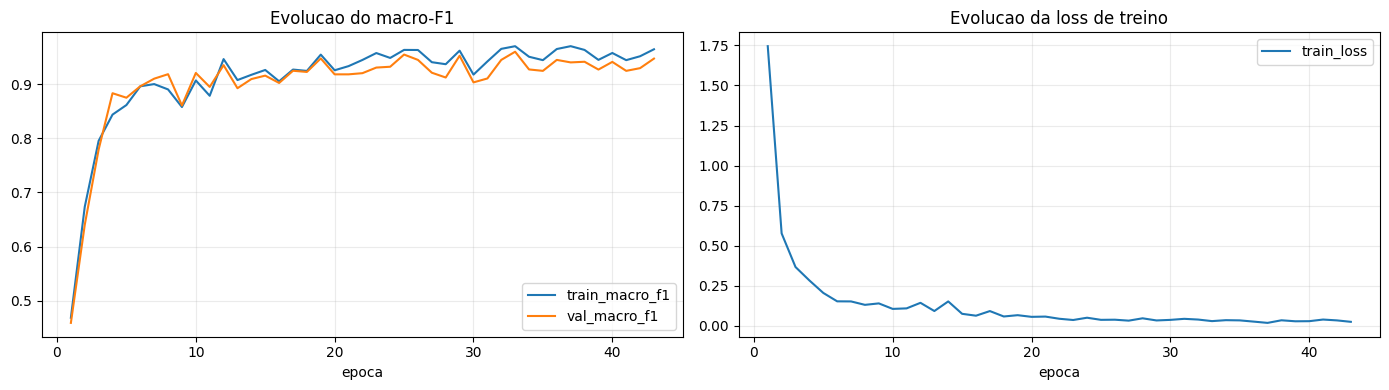

In [7]:
history_df = pd.read_csv(hybrid_summary["history_path"])
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
axes[0].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
axes[0].set_title("Evolucao do macro-F1")
axes[0].set_xlabel("epoca")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[1].set_title("Evolucao da loss de treino")
axes[1].set_xlabel("epoca")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Avaliacao do melhor checkpoint

Depois do treino, carregamos o melhor modelo salvo e medimos o desempenho em validacao e teste.

In [8]:
hybrid_model = load_hybrid_lstm_classifier_visible(hybrid_summary["config_path"])

val_pred = predict_hybrid_lstm_classes_visible(
    hybrid_model,
    val_arrays["X_seq"],
    val_arrays["X_tab"],
)
test_pred = predict_hybrid_lstm_classes_visible(
    hybrid_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
)

val_eval = evaluate_predictions(val_arrays["y"], val_pred, class_labels=bundle.class_labels)
test_eval = evaluate_predictions(test_arrays["y"], test_pred, class_labels=bundle.class_labels)

comparison_df = build_metrics_table(
    {
        "hybrid_lstm_validation": val_eval,
        "hybrid_lstm_test": test_eval,
    }
)
comparison_df

,modelo,accuracy,macro_f1,balanced_accuracy
0,hybrid_lstm_validation,0.955090,0.959556,0.960849
1,hybrid_lstm_test,0.922388,0.926817,0.941495


In [9]:
best_history_row = history_df.loc[history_df["epoch"] == hybrid_summary["best_epoch"]].iloc[0]
metrics_focus_df = pd.DataFrame(
    {
        "etapa": ["validacao", "teste"],
        "accuracy": [val_eval["accuracy"], test_eval["accuracy"]],
        "macro_f1": [val_eval["macro_f1"], test_eval["macro_f1"]],
        "balanced_accuracy": [val_eval["balanced_accuracy"], test_eval["balanced_accuracy"]],
    }
)
display(metrics_focus_df)

generalization_df = pd.DataFrame(
    {
        "indicador": [
            "melhor epoca",
            "macro_f1_treino_na_melhor_epoca",
            "macro_f1_validacao_na_melhor_epoca",
            "gap_treino_validacao",
        ],
        "valor": [
            int(hybrid_summary["best_epoch"]),
            float(best_history_row["train_macro_f1"]),
            float(best_history_row["val_macro_f1"]),
            float(best_history_row["train_macro_f1"] - best_history_row["val_macro_f1"]),
        ],
    }
)
display(generalization_df)

,etapa,accuracy,macro_f1,balanced_accuracy
0,validacao,0.955090,0.959556,0.960849
1,teste,0.922388,0.926817,0.941495


,indicador,valor
0,melhor epoca,33.000000
1,macro_f1_treino_na_melhor_epoca,0.969765
2,macro_f1_validacao_na_melhor_epoca,0.959556
3,gap_treino_validacao,0.010209


In [10]:
export_evaluation_artifacts(val_eval, HYBRID_OUTPUT_DIR, "hybrid_lstm_validation")
export_evaluation_artifacts(test_eval, HYBRID_OUTPUT_DIR, "hybrid_lstm_test")

display(test_eval["classification_report_df"])

,label,precision,recall,f1-score,support
0,0,0.986111,0.797753,0.881988,89.000000
1,1,0.944444,0.850000,0.894737,20.000000
2,2,1.000000,1.000000,1.000000,5.000000
3,3,0.888889,1.000000,0.941176,16.000000
4,4,0.720588,0.942308,0.816667,52.000000
5,5,1.000000,1.000000,1.000000,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.666667,0.857143,0.750000,7.000000
8,8,1.000000,1.000000,1.000000,14.000000
9,9,1.000000,0.967742,0.983607,31.000000


In [11]:
per_class_test_df = (
    test_eval["classification_report_df"]
    .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
    .copy()
)
per_class_test_df["label"] = per_class_test_df["label"].astype(int)
per_class_test_df = per_class_test_df.sort_values(["f1-score", "recall", "precision"])
display(per_class_test_df)

,label,precision,recall,f1-score,support
7,7,0.666667,0.857143,0.750000,7.0
4,4,0.720588,0.942308,0.816667,52.0
0,0,0.986111,0.797753,0.881988,89.0
1,1,0.944444,0.850000,0.894737,20.0
3,3,0.888889,1.000000,0.941176,16.0
9,9,1.000000,0.967742,0.983607,31.0
2,2,1.000000,1.000000,1.000000,5.0
5,5,1.000000,1.000000,1.000000,68.0
6,6,1.000000,1.000000,1.000000,33.0
8,8,1.000000,1.000000,1.000000,14.0


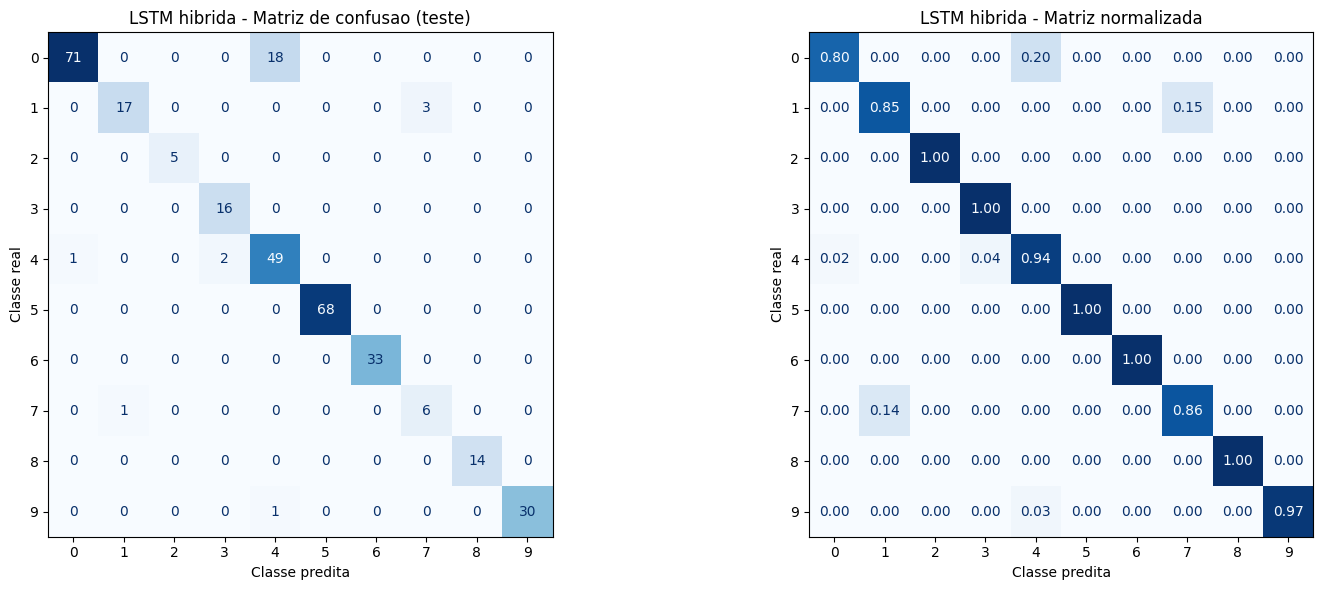

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize=None,
    title="LSTM hibrida - Matriz de confusao (teste)",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
    normalize="true",
    title="LSTM hibrida - Matriz normalizada",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

In [13]:
weakest_rows = per_class_test_df.head(3)

print("Leitura interpretativa da LSTM hibrida")
print()
print(
    f"No conjunto de teste, a rede atingiu accuracy = {test_eval['accuracy']:.4f}, "
    f"macro-F1 = {test_eval['macro_f1']:.4f} e balanced accuracy = {test_eval['balanced_accuracy']:.4f}."
)
print(
    f"A melhor epoca foi a {int(hybrid_summary['best_epoch'])}, com macro-F1 de validacao "
    f"igual a {val_eval['macro_f1']:.4f}."
)
print(
    f"O gap entre macro-F1 de treino e validacao na melhor epoca foi de "
    f"{best_history_row['train_macro_f1'] - best_history_row['val_macro_f1']:.4f}."
)
print()
print("As classes com menor F1 no teste foram:")
for _, row in weakest_rows.iterrows():
    print(
        f"- classe {int(row['label'])}: precision = {row['precision']:.4f}, "
        f"recall = {row['recall']:.4f}, f1 = {row['f1-score']:.4f}, support = {int(row['support'])}"
    )

Leitura interpretativa da LSTM hibrida

No conjunto de teste, a rede atingiu accuracy = 0.9224, macro-F1 = 0.9268 e balanced accuracy = 0.9415.
A melhor epoca foi a 33, com macro-F1 de validacao igual a 0.9596.
O gap entre macro-F1 de treino e validacao na melhor epoca foi de 0.0102.

As classes com menor F1 no teste foram:
- classe 7: precision = 0.6667, recall = 0.8571, f1 = 0.7500, support = 7
- classe 4: precision = 0.7206, recall = 0.9423, f1 = 0.8167, support = 52
- classe 0: precision = 0.9861, recall = 0.7978, f1 = 0.8820, support = 89


## Leitura didatica dos resultados

A avaliacao desta arquitetura deve responder tres perguntas:

1. Ela melhorou em relacao a `versao8`?
2. Ela recuperou ou superou a melhor `LSTM` anterior da `versao6`?
3. Ela conseguiu se aproximar das baselines tabulares?

O notebook seguinte faz exatamente essa comparacao.